In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
data = pd.read_csv("/content/bank-full.csv", sep=';')
data.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [4]:
print("Shape:", data.shape)
data.head()

Shape: (45211, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [5]:
data['y'] = data['y'].map({'yes':1, 'no':0})

print("\nMissing Values:\n", data.isnull().sum())


Missing Values:
 age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64


In [6]:
total_visitors = len(data)


leads = len(data[data['contact'] != 'unknown'])


customers = data['y'].sum()

print("\nFunnel Numbers:")
print("Visitors:", total_visitors)
print("Leads:", leads)
print("Customers:", customers)


Funnel Numbers:
Visitors: 45211
Leads: 32191
Customers: 5289


In [7]:
visitor_to_lead = leads / total_visitors
lead_to_customer = customers / leads
overall_conversion = customers / total_visitors

print("\nConversion Rates:")
print("Visitor → Lead:", round(visitor_to_lead,3))
print("Lead → Customer:", round(lead_to_customer,3))
print("Overall Conversion:", round(overall_conversion,3))



Conversion Rates:
Visitor → Lead: 0.712
Lead → Customer: 0.164
Overall Conversion: 0.117


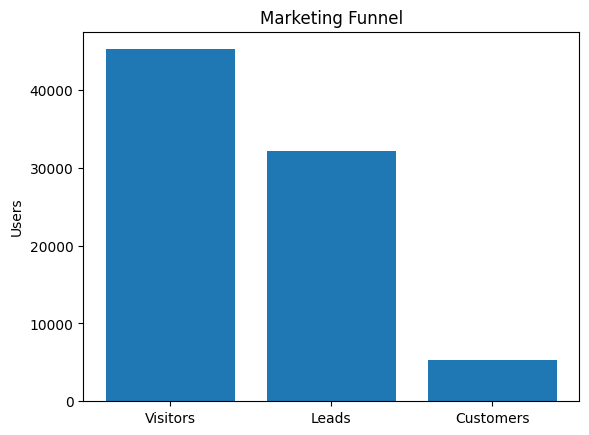

In [8]:
stages = ['Visitors','Leads','Customers']
values = [total_visitors, leads, customers]

plt.figure()
plt.bar(stages, values)
plt.title("Marketing Funnel")
plt.ylabel("Users")
plt.show()

In [9]:
print("\nDrop-offs:")
print("Visitors → Leads:", total_visitors - leads)
print("Leads → Customers:", leads - customers)


Drop-offs:
Visitors → Leads: 13020
Leads → Customers: 26902



Channel Performance:
           count   sum  conversion_rate
contact                                
cellular   29285  4369         0.149189
telephone   2906   390         0.134205
unknown    13020   530         0.040707


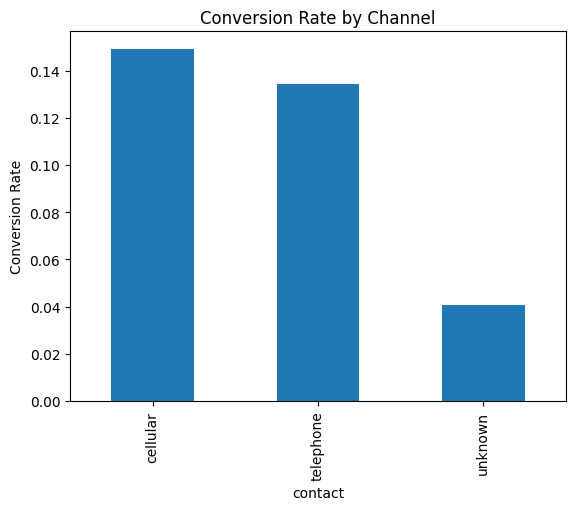

In [10]:
channel_perf = data.groupby('contact')['y'].agg(['count','sum'])

channel_perf['conversion_rate'] = channel_perf['sum'] / channel_perf['count']

print("\nChannel Performance:")
print(channel_perf)


channel_perf['conversion_rate'].plot(kind='bar')
plt.title("Conversion Rate by Channel")
plt.ylabel("Conversion Rate")
plt.show()


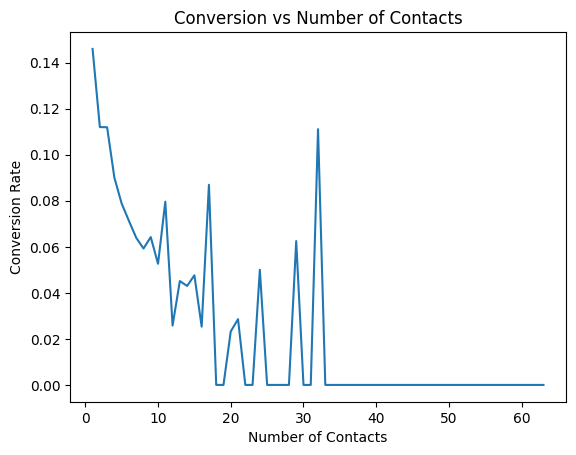

In [11]:
campaign_perf = data.groupby('campaign')['y'].mean()

plt.figure()
plt.plot(campaign_perf)
plt.title("Conversion vs Number of Contacts")
plt.xlabel("Number of Contacts")
plt.ylabel("Conversion Rate")
plt.show()

/tmp/ipykernel_1884/3751719783.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_perf = data.groupby('age_group')['y'].mean()


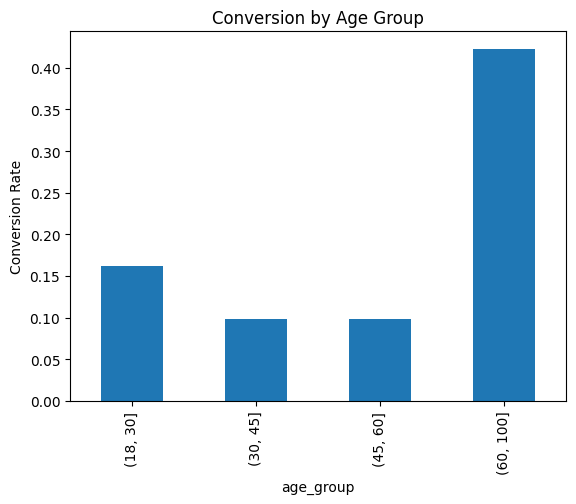

In [12]:
data['age_group'] = pd.cut(data['age'], bins=[18,30,45,60,100])

age_perf = data.groupby('age_group')['y'].mean()

age_perf.plot(kind='bar')
plt.title("Conversion by Age Group")
plt.ylabel("Conversion Rate")
plt.show()


In [13]:
print("\nKey Insights:")

if visitor_to_lead < 0.5:
    print("- Large drop at initial stage (contact issues)")

if lead_to_customer < 0.3:
    print("- Leads are not converting efficiently")

best_channel = channel_perf['conversion_rate'].idxmax()
print(f"- Best channel: {best_channel}")

print("- More campaign calls reduce conversion (customer fatigue)")


Key Insights:
- Leads are not converting efficiently
- Best channel: cellular
- More campaign calls reduce conversion (customer fatigue)


In [14]:
print("\nRecommendations:")

print("- Improve targeting before contacting users")
print("- Focus on high-converting channels")
print("- Reduce excessive follow-ups")
print("- Personalize campaigns")
print("- Optimize call scripts for better conversion")


Recommendations:
- Improve targeting before contacting users
- Focus on high-converting channels
- Reduce excessive follow-ups
- Personalize campaigns
- Optimize call scripts for better conversion
